# RoBERTa


In [ ]:
import os
import pandas as pd
from datasets import Dataset

# ✅ تعطيل wandb نهائيًا
os.environ["WANDB_DISABLED"] = "true"

# ✅ تحميل البيانات
file_path = "/content/Customer_Support_Assistant_Dataset.csv"

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    raise ValueError("❌ ملف البيانات غير موجود، تأكد من رفع الملف الصحيح!")

# ✅ إزالة العمود غير المطلوب إذا كان موجودًا
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ✅ التحقق من الأعمدة الصحيحة
expected_columns = ["Customer_Query", "Support_Response"]
missing_columns = [col for col in expected_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"❌ الأعمدة التالية مفقودة في الملف: {missing_columns}. تأكد من تحميل ملف البيانات الصحيح!")

# ✅ تحديد الأعمدة الخاصة بالسؤال والإجابة
input_column = "Customer_Query"
response_column = "Support_Response"

print(f"📌 تم تحديد السؤال في العمود: {input_column}")
print(f"📌 تم تحديد الإجابة في العمود: {response_column}")

# ✅ تحويل `DataFrame` إلى `Dataset` لاستخدامه مع `Hugging Face`
dataset = Dataset.from_pandas(df)

# ✅ عرض أول 5 صفوف من البيانات للتحقق
print(df.head())


📌 تم تحديد السؤال في العمود: Customer_Query
📌 تم تحديد الإجابة في العمود: Support_Response
   Customer_ID   Query_Category  \
0            1  Product Inquiry   
1            2   Account Issues   
2            3  Product Inquiry   
3            4          Billing   
4            5  Product Inquiry   

                                      Customer_Query  \
0               Do you have any discounts available?   
1  I forgot my login details, how can I recover m...   
2               Do you have any discounts available?   
3                Why was I charged twice this month?   
4         Is this product compatible with my device?   

                                    Support_Response Sentiment  Response_Time  \
0  This product has the following features: [Feat...  Positive            232   
1  You can recover your account by clicking on 'F...   Neutral            128   
2  This product is compatible with most devices. ...  Negative              9   
3  We have initiated your refund requ

In [ ]:
# تحميل التوكنيزر
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# دالة لتحويل البيانات إلى توكنز مع معالجة labels بشكل صحيح
def tokenize_function(examples):
    inputs = tokenizer(examples[input_column], padding="max_length", truncation=True)
    targets = tokenizer(examples[response_column], padding="max_length", truncation=True)["input_ids"]

    # استخدام فقط التوكن الأول كإخراج لتجنب مشاكل `batch_size`
    labels = [target[0] for target in targets]

    inputs["labels"] = labels
    return inputs

# تطبيق التحويل
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# إزالة الأعمدة غير الضرورية
tokenized_dataset = tokenized_dataset.remove_columns([input_column, response_column])
tokenized_dataset.set_format("torch")

print("✅ البيانات جاهزة للتدريب!")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ البيانات جاهزة للتدريب!


In [ ]:
# تحميل النموذج
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(df[response_column].unique()))

# إعدادات التدريب
training_args = TrainingArguments(
    output_dir="./roberta_chatbot",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,  # يجب أن يتطابق مع labels
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    remove_unused_columns=False,  # منع حذف الأعمدة المهمة تلقائيًا
    report_to="none",  # تعطيل wandb نهائيًا
)

# تجهيز `Trainer`
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset,  # استخدام نفس البيانات للتقييم
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
num_training_rounds = 1  # عدد الدورات التدريبية
checkpoint_path = "./roberta_chatbot/checkpoint-last"

for round_num in range(1, num_training_rounds + 1):
    print(f"\n🔄 Training Round {round_num}/{num_training_rounds}...")

    if os.path.exists(checkpoint_path):
        trainer.train(resume_from_checkpoint=checkpoint_path)  # استئناف من آخر نقطة حفظ
    else:
        trainer.train()  # تدريب جديد إذا لم يكن هناك Checkpoint

    print(f"✅ Finished Training Round {round_num}/{num_training_rounds}")

    # حفظ النموذج بعد كل دورة تدريبية
    model.save_pretrained(f"./roberta_trained_chatbot_round_{round_num}")
    tokenizer.save_pretrained(f"./roberta_trained_chatbot_round_{round_num}")

    # تقييم النموذج بعد كل دورة
    eval_results = trainer.evaluate()
    print(f"📊 Evaluation Results (Round {round_num}):", eval_results)

# حفظ النموذج النهائي فقط
model.save_pretrained("./roberta_trained_chatbot_final")
tokenizer.save_pretrained("./roberta_trained_chatbot_final")
print("✅ Model training complete and saved successfully.")


🔄 Training Round 1/1...


Epoch,Training Loss,Validation Loss
1,No log,0.000263
2,0.219000,0.000123
3,0.000200,0.000099


✅ Finished Training Round 1/1


📊 Evaluation Results (Round 1): {'eval_loss': 9.885613690130413e-05, 'eval_runtime': 91.2366, 'eval_samples_per_second': 40.828, 'eval_steps_per_second': 5.108, 'epoch': 3.0}
✅ Model training complete and saved successfully.


In [ ]:
model.save_pretrained("./roberta_trained_chatbot_final")
tokenizer.save_pretrained("./roberta_trained_chatbot_final")
print("✅ Model saved successfully.")

✅ Model saved successfully.


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# تحميل النموذج والتوكنيزر
model_name = "./roberta_trained_chatbot_final"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to("cuda")

print("✅ Model loaded successfully.")


✅ Model loaded successfully.


In [ ]:
from sklearn.metrics import accuracy_score

# تقييم النموذج على مجموعة التقييم
eval_results = trainer.evaluate()
print(f"📊 Raw Evaluation Results: {eval_results}")

# استخراج التوقعات
predictions = trainer.predict(tokenized_dataset)

# حساب الدقة
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)  # اختيار الفئة ذات الاحتمالية الأعلى
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy}

accuracy = compute_metrics((predictions.predictions, predictions.label_ids))
print(f"✅ Test Accuracy: {accuracy['accuracy']:.4f}")


📊 Raw Evaluation Results: {'eval_loss': 9.885613690130413e-05, 'eval_runtime': 92.361, 'eval_samples_per_second': 40.331, 'eval_steps_per_second': 5.045, 'epoch': 3.0}
✅ Test Accuracy: 1.0000


In [ ]:
import torch

# إضافة `pad_token` لتجنب الخطأ
tokenizer.pad_token = tokenizer.eos_token

# دالة التفاعل مع الشات بوت
def chat_with_roberta(user_input):
    inputs = tokenizer(user_input, return_tensors="pt", padding=True, truncation=True).to("cuda")

    # تشغيل النموذج للحصول على التوقعات
    with torch.no_grad():
        outputs = model(**inputs)

    # استخراج الفئة المتوقعة كعدد صحيح
    predicted_class = torch.argmax(outputs.logits, dim=-1).cpu().numpy().tolist()

    # التأكد من أن `predicted_class` عدد صحيح
    if isinstance(predicted_class, list):
        predicted_class = predicted_class[0]

    # استخراج الرد الصحيح بناءً على الفئة المتوقعة
    possible_answers = df["answer"].unique().tolist()

    # التحقق من أن `predicted_class` صالح لاختيار إجابة
    if 0 <= predicted_class < len(possible_answers):
        bot_response = possible_answers[predicted_class]
    else:
        bot_response = "I don't understand."

    return bot_response

# تجربة المحادثة
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Bot: Goodbye! 👋")
        break
    bot_response = chat_with_roberta(user_input)
    print(f"Bot: {bot_response}")


You: ?Who did you vote for
Bot: i'm fine. how about yourself?
You: Who did you vote for?
Bot: i'm fine. how about yourself?
You: How are you?
Bot: i'm fine. how about yourself?
You: I'm fine
Bot: i'm fine. how about yourself?
You: how the weather today?
Bot: i'm fine. how about yourself?
You: exit
Bot: Goodbye! 👋


In [ ]:
test_samples = ["Who did you vote for?", "How are you?", "How's the weather today?"]
for sample in test_samples:
    inputs = tokenizer(sample, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)
    print(f"Input: {sample} → Prediction: {torch.argmax(outputs.logits, dim=-1).item()}")


Input: Who did you vote for? → Prediction: 0
Input: How are you? → Prediction: 0
Input: How's the weather today? → Prediction: 0


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# تحميل نموذج GPT-2 بدلاً من RoBERTa
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda")

def chat_with_gpt(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    output = model.generate(**inputs, max_length=50)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# تجربة المحادثة
print(chat_with_gpt("Hello, how are you?"))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Hello, how are you?

I'm a little bit of a nerd. I'm a big nerd. I'm a big nerd. I'm a big nerd. I'm a big nerd. I'm a big nerd. I'm a


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# تحميل نموذج GPT-2
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda")

def chat_with_gpt(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # تحسين إعدادات التوليد لمنع التكرار وتحسين التنوع
    output = model.generate(
        **inputs,
        max_new_tokens=50,  # الحد الأقصى لعدد الكلمات في الرد
        temperature=0.7,  # تقليل العشوائية (كلما قل، كانت الردود أكثر دقة)
        top_p=0.9,  # ضبط الاحتمالية لإخراج أكثر طبيعية
        repetition_penalty=1.2,  # منع التكرار في الردود
        pad_token_id=tokenizer.eos_token_id  # منع الخطأ بسبب نقص `pad_token`
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# تجربة المحادثة
print(chat_with_gpt("Hello, how are you?"))


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Hello, how are you?
I'm a little bit of an idiot. I've been doing this for years and it's just not working out so well anymore! It was like my life had changed forever when the first time we met in high school (laughs). But now


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# تحميل نموذج GPT-2
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda")

def chat_with_gpt(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # تحسين التوليد بإضافة `do_sample=True`
    output = model.generate(
        **inputs,
        max_new_tokens=50,  # الحد الأقصى لعدد الكلمات في الرد
        temperature=0.7,  # تقليل العشوائية (كلما قل، كانت الردود أكثر دقة)
        top_p=0.9,  # ضبط الاحتمالية لإخراج أكثر طبيعية
        repetition_penalty=1.2,  # منع التكرار في الردود
        do_sample=True,  # تفعيل توليد النصوص العشوائي
        pad_token_id=tokenizer.eos_token_id  # منع الخطأ بسبب نقص `pad_token`
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# تجربة المحادثة
print(chat_with_gpt("Hello, how are you?"))


Hello, how are you?
Cindy: Well… we have two of them. One is the one that was stolen from our house and I've been here for a month now so it's not like there hasn't happened before or something but... this place has really


In [ ]:
print(df["answer"].value_counts())  # معرفة عدد مرات ظهور كل إجابة
print(df.head())  # عرض أول 5 صفوف لمعرفة العلاقة بين السؤال والجواب


answer
what do you mean?                  22
why not?                           16
what happened?                     10
why is that?                        9
of course.                          8
                                   ..
let me help you.                    1
what does "mi" mean?                1
"mi" stands for middle initial.     1
what does "mm/dd/yy" mean?          1
i meet too many jerks.              1
Name: count, Length: 3512, dtype: int64
                              question  \
0               hi, how are you doing?   
1        i'm fine. how about yourself?   
2  i'm pretty good. thanks for asking.   
3    no problem. so how have you been?   
4     i've been great. what about you?   

                                     answer  
0             i'm fine. how about yourself?  
1       i'm pretty good. thanks for asking.  
2         no problem. so how have you been?  
3          i've been great. what about you?  
4  i've been good. i'm in school right now.  


In [ ]:
pip install sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 41.8 MB/s eta 0:00:00


In [ ]:
import torch
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# تحميل النموذج الخاص بتحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# تحويل جميع الأسئلة إلى تمثيلات عددية
question_embeddings = embedding_model.encode(df["question"].tolist())

# إنشاء فهرس `FAISS` للبحث السريع عن الجمل المشابهة
index = faiss.IndexFlatL2(question_embeddings.shape[1])  # L2 يعني المسافة الإقليدية
index.add(np.array(question_embeddings, dtype=np.float32))

# دالة البحث عن أفضل إجابة باستخدام `FAISS`
def get_best_match(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["answer"]

# دالة المحادثة مع الشات بوت
def chat_with_bot(user_input):
    bot_response = get_best_match(user_input)
    return bot_response

# تجربة المحادثة
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Bot: Goodbye! 👋")
        break
    bot_response = chat_with_bot(user_input)
    print(f"Bot: {bot_response}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

You: hi, how are you doing?
Bot: i'm fine. how about yourself?
You: i'm pretty good. thanks for asking.
Bot: no problem. so how have you been?
You: i've been great. what about you?
Bot: i've been good. i'm in school right now.
You: what school do you go to?
Bot: i go to pcc.
You: do you like it there?
Bot: it's okay. it's a really big campus.
You: which school do you attend?
Bot: i'm attending pcc right now.
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# تحميل النموذج الخاص بتحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# تحويل جميع الإجابات إلى تمثيلات عددية
answer_embeddings = embedding_model.encode(df["answer"].tolist())

# إنشاء فهرس `FAISS` للبحث السريع عن الجمل المشابهة
index = faiss.IndexFlatL2(answer_embeddings.shape[1])  # L2 يعني المسافة الإقليدية
index.add(np.array(answer_embeddings, dtype=np.float32))

# دالة البحث عن أفضل سؤال بناءً على إجابة المستخدم
def get_best_question(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["question"]

# دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("Bot: Let's start! I will ask you questions, and you can answer.")
    while True:
        # البوت يطرح سؤالاً من البيانات العشوائية
        question = df["question"].sample(1).values[0]
        print(f"Bot: {question}")

        # المستخدم يجيب
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # تحليل إجابة المستخدم للعثور على أقرب سؤال مشابه في البيانات
        next_question = get_best_question(user_input)
        print(f"Bot: Interesting! Here's another question: {next_question}")

# تشغيل الشات بوت
chat_with_bot()


Bot: Let's start! I will ask you questions, and you can answer.
Bot: i want to. i heard it's going to be really fun.
You: ?What kind of event is it That sounds great
Bot: Interesting! Here's another question: what's that?
Bot: he can, but the people around him can't.
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# تحميل البيانات الأصلية (تأكد أن الملف موجود في نفس المسار)
file_path = "/content/Conversation.csv"
df = pd.read_csv(file_path)

# التأكد من أن الأعمدة موجودة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# تحميل النموذج الخاص بتحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# تحويل جميع الإجابات إلى تمثيلات عددية
answer_embeddings = embedding_model.encode(df["answer"].tolist())

# إنشاء فهرس `FAISS` للبحث السريع عن الجمل المشابهة
index = faiss.IndexFlatL2(answer_embeddings.shape[1])  # L2 يعني المسافة الإقليدية
index.add(np.array(answer_embeddings, dtype=np.float32))

# دالة البحث عن أفضل سؤال بناءً على إجابة المستخدم
def get_best_question(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["question"]

# دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("Bot: Let's start! I will ask you questions, and you can answer.")
    while True:
        # البوت يطرح سؤالاً من البيانات العشوائية
        question = df["question"].sample(1).values[0]
        print(f"Bot: {question}")

        # المستخدم يجيب
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # تحليل إجابة المستخدم للعثور على أقرب سؤال مشابه في البيانات
        next_question = get_best_question(user_input)
        print(f"Bot: Interesting! Here's another question: {next_question}")

# تشغيل الشات بوت
chat_with_bot()


Bot: Let's start! I will ask you questions, and you can answer.
Bot: yesterday a pen fell through my pants onto my shoe.
You:  It was an acciden
Bot: Interesting! Here's another question: that was a huge fire in santa barbara.
Bot: oh, no. we can walk right in.
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات من Conversation.csv
file_path = "/content/Conversation.csv"
df = pd.read_csv(file_path)

# ✅ التحقق من الأعمدة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# ✅ تحميل نموذج تحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ تحويل جميع الإجابات إلى تمثيلات عددية
answer_embeddings = embedding_model.encode(df["answer"].tolist())

# ✅ إنشاء فهرس `FAISS` باستخدام `cosine similarity`
index = faiss.IndexFlatIP(answer_embeddings.shape[1])  # Inner Product بدل L2
faiss.normalize_L2(answer_embeddings)  # تطبيع التمثيلات العددية لتحسين الدقة
index.add(answer_embeddings)

# ✅ دالة البحث عن أفضل سؤال بناءً على إجابة المستخدم
def get_best_question(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["question"]

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("Bot: Let's start! I will ask you questions, and you can answer.")
    while True:
        # البوت يطرح سؤالًا عشوائيًا من البيانات
        question = df["question"].sample(1).values[0]
        print(f"Bot: {question}")

        # المستخدم يجيب
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # تحليل إجابة المستخدم والعثور على أقرب سؤال
        next_question = get_best_question(user_input)
        print(f"Bot: Interesting! Here's another question: {next_question}")

# ✅ تشغيل الشات بوت
chat_with_bot()


Bot: Let's start! I will ask you questions, and you can answer.
Bot: i started shopping at the dollar store.
You: ?item favorite your What's sometimes too there shop I؟
Bot: Interesting! Here's another question: how are you doing that?
Bot: oh, yes, here it is. do you want a sandwich?
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات من Conversation.csv
file_path = "/content/Conversation.csv"
df = pd.read_csv(file_path)

# ✅ التحقق من الأعمدة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# ✅ تحميل نموذج تحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ تحويل جميع الإجابات إلى تمثيلات عددية
answer_embeddings = embedding_model.encode(df["answer"].tolist())

# ✅ إنشاء فهرس `FAISS` باستخدام `cosine similarity`
index = faiss.IndexFlatIP(answer_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(answer_embeddings)  # تطبيع التمثيلات العددية لتحسين الدقة
index.add(answer_embeddings)

# ✅ دالة البحث عن أفضل سؤال بناءً على إجابة المستخدم
def get_best_question(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد
    _, closest_matches = index.search(user_embedding, 5)  # البحث عن 5 جمل واختيار الأفضل

    # البحث عن أقرب سؤال منطقي بين الخيارات
    best_question = None
    for match_idx in closest_matches[0]:
        candidate_question = df.iloc[match_idx]["question"]
        if candidate_question.lower() != user_input.lower():  # تجنب تكرار نفس السؤال
            best_question = candidate_question
            break  # اختيار أول سؤال مناسب

    return best_question if best_question else "I don't understand."

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("Bot: Let's start! I will ask you questions, and you can answer.")
    while True:
        # البوت يطرح سؤالًا عشوائيًا من البيانات
        question = df["question"].sample(1).values[0]
        print(f"Bot: {question}")

        # المستخدم يجيب
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # تحليل إجابة المستخدم والعثور على أقرب سؤال منطقي
        next_question = get_best_question(user_input)
        print(f"Bot: Interesting! Here's another question: {next_question}")

# ✅ تشغيل الشات بوت
chat_with_bot()


Bot: Let's start! I will ask you questions, and you can answer.
Bot: so, i'll just buy another one.
You: why?
Bot: Interesting! Here's another question: you should wet your shirt immediately.
Bot: don't ask me.
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات من Conversation.csv
file_path = "/content/Conversation.csv"  # تأكد من المسار الصحيح للملف
df = pd.read_csv(file_path)

# ✅ التحقق من الأعمدة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# ✅ تحميل نموذج تحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ تحويل جميع الأسئلة إلى تمثيلات عددية
question_embeddings = embedding_model.encode(df["question"].tolist())

# ✅ إنشاء فهرس `FAISS` باستخدام `cosine similarity`
index = faiss.IndexFlatIP(question_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(question_embeddings)  # تطبيع التمثيلات العددية لتحسين الدقة
index.add(question_embeddings)

# ✅ دالة البحث عن أفضل إجابة بناءً على سؤال المستخدم
def get_best_answer(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["answer"]

# ✅ دالة المحادثة مع الشات بوت (المستخدم يسأل والبوت يجيب)
def chat_with_bot():
    print("Bot: Hello! Ask me anything, and I will answer based on my knowledge.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # البحث عن أفضل إجابة من البيانات
        bot_response = get_best_answer(user_input)
        print(f"Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


Bot: Hello! Ask me anything, and I will answer based on my knowledge.
You: Do you offer international shippin?
Bot: which one do you want?
You: How can I update my payment method?
Bot: and it gives you money?
You: How can I reset my password?
Bot: oh, no. that's bad news.
You: exit
Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات من Conversation.csv
file_path = "/content/Conversation.csv"  # تأكد من المسار الصحيح للملف
df = pd.read_csv(file_path)

# ✅ التحقق من الأعمدة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# ✅ تحميل نموذج تحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ تحويل جميع الأسئلة إلى تمثيلات عددية
question_embeddings = embedding_model.encode(df["question"].tolist())

# ✅ إنشاء فهرس `FAISS` باستخدام `cosine similarity`
index = faiss.IndexFlatIP(question_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(question_embeddings)  # تطبيع التمثيلات العددية لتحسين الدقة
index.add(question_embeddings)

# ✅ دالة البحث عن أفضل إجابة بناءً على سؤال المستخدم
def get_best_answer(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب

    # ✅ التأكد من أن الإجابة ليست عشوائية
    if 0 <= best_match_idx < len(df):
        return df.iloc[best_match_idx]["answer"]
    return "I'm not sure, can you rephrase that?"

# ✅ دالة المحادثة مع الشات بوت (المستخدم يسأل والبوت يجيب)
def chat_with_bot():
    print("Bot: Hello! Ask me anything, and I will answer based on my knowledge.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # البحث عن أفضل إجابة من البيانات
        bot_response = get_best_answer(user_input)
        print(f"Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


Bot: Hello! Ask me anything, and I will answer based on my knowledge.
You: How can I reset my password?
Bot: oh, no. that's bad news.
You: exit
Bot: Goodbye! 👋


In [ ]:
print(df.head())  # عرض أول 5 صفوف من البيانات
print(df.sample(5))  # عرض 5 صفوف عشوائية


   Unnamed: 0                             question  \
0           0               hi, how are you doing?   
1           1        i'm fine. how about yourself?   
2           2  i'm pretty good. thanks for asking.   
3           3    no problem. so how have you been?   
4           4     i've been great. what about you?   

                                     answer  
0             i'm fine. how about yourself?  
1       i'm pretty good. thanks for asking.  
2         no problem. so how have you been?  
3          i've been great. what about you?  
4  i've been good. i'm in school right now.  
      Unnamed: 0                                           question  \
3657        3657    well, maybe it's from the pollution in the air.   
3654        3654                                you might be right.   
3674        3674  i think i know the difference between picking ...   
111          111                         it sounds like it will be.   
3133        3133                     i don't

In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات من Conversation.csv
file_path = "/content/Conversation.csv"  # تأكد من المسار الصحيح للملف
df = pd.read_csv(file_path)

# ✅ التحقق من الأعمدة
if "question" not in df.columns or "answer" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف Conversation.csv يحتوي على أعمدة 'question' و 'answer'!")

# ✅ تحميل نموذج تحويل النصوص إلى تمثيلات عددية (`embeddings`)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ تحويل جميع الأسئلة إلى تمثيلات عددية
question_embeddings = embedding_model.encode(df["question"].tolist())

# ✅ إنشاء فهرس `FAISS` باستخدام `cosine similarity`
index = faiss.IndexFlatIP(question_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(question_embeddings)  # تطبيع التمثيلات العددية لتحسين الدقة
index.add(question_embeddings)

# ✅ دالة البحث عن أفضل إجابة بناءً على سؤال المستخدم
def get_best_answer(user_input, threshold=0.7):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد
    distances, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب جملة واحدة فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    similarity_score = distances[0][0]  # استخراج نسبة التشابه

    # ✅ إذا كان التشابه أقل من `threshold`، لا يعطِ إجابة غير صحيحة
    if similarity_score < threshold:
        return "I'm not sure about that. Can you ask in a different way?"

    return df.iloc[best_match_idx]["answer"]

# ✅ دالة المحادثة مع الشات بوت (المستخدم يسأل والبوت يجيب)
def chat_with_bot():
    print("Bot: Hello! Ask me anything, and I will answer based on my knowledge.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("Bot: Goodbye! 👋")
            break

        # البحث عن أفضل إجابة من البيانات
        bot_response = get_best_answer(user_input)
        print(f"Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


Bot: Hello! Ask me anything, and I will answer based on my knowledge.
You: do you think anyone will come to my funeral?
Bot: of course.
You: when is he coming?
Bot: he's busy. he said next week.
You: exit
Bot: Goodbye! 👋


In [ ]:
import pandas as pd

# تحميل البيانات الجديدة
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# عرض أول 5 صفوف لمعرفة أسماء الأعمدة المتاحة
print(df.head())

# عرض أسماء الأعمدة
print("📌 أسماء الأعمدة المتاحة:", df.columns)


   Customer_ID   Query_Category  \
0            1  Product Inquiry   
1            2   Account Issues   
2            3  Product Inquiry   
3            4          Billing   
4            5  Product Inquiry   

                                      Customer_Query  \
0               Do you have any discounts available?   
1  I forgot my login details, how can I recover m...   
2               Do you have any discounts available?   
3                Why was I charged twice this month?   
4         Is this product compatible with my device?   

                                    Support_Response Sentiment  Response_Time  \
0  This product has the following features: [Feat...  Positive            232   
1  You can recover your account by clicking on 'F...   Neutral            128   
2  This product is compatible with most devices. ...  Negative              9   
3  We have initiated your refund request. It shou...  Positive            233   
4  This product has the following features: [Fe

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

# ✅ تحديد الأعمدة الصحيحة بناءً على بياناتك
input_column = "Customer_Query"  # عمود الأسئلة
response_column = "Support_Response"  # عمود الإجابات

# ✅ تحويل بيانات `pandas` إلى `Dataset` متوافق مع `Hugging Face`
dataset = Dataset.from_pandas(df)

# ✅ تحميل التوكنيزر
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# ✅ دالة تحويل البيانات إلى توكنز
def tokenize_function(examples):
    inputs = tokenizer(examples[input_column], padding="max_length", truncation=True, max_length=128)
    targets = tokenizer(examples[response_column], padding="max_length", truncation=True, max_length=128)["input_ids"]

    # ✅ استخدام `targets` كـ labels
    inputs["labels"] = targets
    return inputs

# ✅ تطبيق التحويل
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# ✅ إزالة الأعمدة غير الضرورية
tokenized_dataset = tokenized_dataset.remove_columns([input_column, response_column, "Customer_ID", "Query_Category", "Sentiment", "Response_Time", "Resolution_Status"])
tokenized_dataset.set_format("torch")

print("✅ البيانات جاهزة للتدريب!")


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ البيانات جاهزة للتدريب!


In [ ]:
pip install transformers datasets torch


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

# ✅ تحديد الأعمدة الصحيحة بناءً على بياناتك
input_column = "Customer_Query"  # عمود الأسئلة
response_column = "Support_Response"  # عمود الإجابات

# ✅ إنشاء قاموس لتحويل الإجابات إلى أرقام (`label_map`)
df = df.dropna(subset=[input_column, response_column])  # إزالة أي صفوف تحتوي على قيم فارغة
unique_responses = df[response_column].unique().tolist()  # حفظ جميع الإجابات الفريدة في قائمة
label_map = {response: i for i, response in enumerate(unique_responses)}
df["label"] = df[response_column].map(label_map)  # تحويل الإجابات إلى أرقام

# ✅ تحويل بيانات `pandas` إلى `Dataset`
dataset = Dataset.from_pandas(df)

# ✅ تحميل التوكنيزر
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# ✅ دالة تحويل البيانات إلى توكنز
def tokenize_function(examples):
    inputs = tokenizer(examples[input_column], padding="max_length", truncation=True, max_length=128)
    inputs["labels"] = examples["label"]
    return inputs

# ✅ تطبيق التحويل
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# ✅ إزالة الأعمدة غير الضرورية
tokenized_dataset = tokenized_dataset.remove_columns([input_column, response_column, "Customer_ID", "Query_Category", "Sentiment", "Response_Time", "Resolution_Status", "label"])
tokenized_dataset.set_format("torch")

print("✅ البيانات جاهزة للتدريب!")


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ البيانات جاهزة للتدريب!


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ✅ تحميل نموذج RoBERTa مع رأس التصنيف المناسب لعدد الفئات
num_labels = len(unique_responses)  # عدد التصنيفات الفريدة
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=num_labels)

# ✅ إعدادات التدريب
training_args = TrainingArguments(
    output_dir="./roberta_customer_support",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,  # سنكرر التدريب باستخدام `loop`
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_total_limit=2,
    push_to_hub=False,
)

# ✅ تقسيم البيانات إلى تدريب واختبار (80% تدريب - 20% اختبار)
split_dataset = tokenized_dataset.train_test_split(test_size=0.2)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

# ✅ إعداد المدرب `Trainer`
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# ✅ بدء التدريب باستخدام `Loop`
num_training_rounds = 1 # عدد جولات التدريب
for round_num in range(1, num_training_rounds + 1):
    print(f"\n🔄 Training Round {round_num}/{num_training_rounds}...")
    trainer.train()

    # حفظ النموذج بعد كل دورة تدريبية
    model.save_pretrained(f"./roberta_trained_round_{round_num}")
    tokenizer.save_pretrained(f"./roberta_trained_round_{round_num}")

    print(f"✅ Finished Training Round {round_num}/{num_training_rounds}")

    # تقييم النموذج بعد كل دورة
    eval_results = trainer.evaluate()
    print(f"📊 Evaluation Results (Round {round_num}):", eval_results)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



🔄 Training Round 1/1...


Epoch,Training Loss,Validation Loss
1,1.155800,1.132141
2,1.161000,1.138986
3,1.093100,1.115907


✅ Finished Training Round 1/1


📊 Evaluation Results (Round 1): {'eval_loss': 1.1159067153930664, 'eval_runtime': 6.2297, 'eval_samples_per_second': 160.52, 'eval_steps_per_second': 20.065, 'epoch': 3.0}


In [ ]:
import torch
from transformers import Trainer

# ✅ استخدام المدرب `Trainer` لاختبار النموذج على نفس البيانات
eval_results = trainer.evaluate()

print("📊 Evaluation on Customer Support Dataset:")
print(eval_results)


📊 Evaluation on Customer Support Dataset:
{'eval_loss': 1.1159067153930664, 'eval_runtime': 6.5212, 'eval_samples_per_second': 153.345, 'eval_steps_per_second': 19.168, 'epoch': 3.0}


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل النموذج على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية على دفعات (`batch processing`)
batch_size = 256  # معالجة 256 جملة في كل مرة لتوفير الذاكرة
query_embeddings = []

for i in range(0, len(df), batch_size):
    batch_queries = df["Customer_Query"][i : i + batch_size].tolist()
    batch_embeddings = embedding_model.encode(batch_queries)
    query_embeddings.append(batch_embeddings)

# ✅ تحويل القائمة إلى مصفوفة `NumPy`
query_embeddings = np.vstack(query_embeddings)

# ✅ إنشاء فهرس `FAISS` للبحث السريع
index = faiss.IndexFlatL2(query_embeddings.shape[1])  # L2 المسافة الإقليدية
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة بناءً على سؤال المستخدم
def get_best_answer(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    _, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب استفسار واحد فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    return df.iloc[best_match_idx]["Support_Response"]

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


🤖 Bot: Hello! Ask me anything about our services.
You: Where are your stores located?
🤖 Bot: You can contact customer service via phone, email, or live chat.
You: My account was suspended, how can I reactivate it?
🤖 Bot: You can recover your account by clicking on 'Forgot Password' and following the steps.
You: How can I contact customer service?
🤖 Bot: Our store locations can be found on our website under 'Store Locator'.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل النموذج على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية (`embeddings`)
query_embeddings = embedding_model.encode(df["Customer_Query"].tolist())

# ✅ استخدام `cosine similarity` بدلاً من `L2 distance` لتحسين البحث
index = faiss.IndexFlatIP(query_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(query_embeddings)  # تطبيع البيانات لتناسب `cosine similarity`
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة بناءً على سؤال المستخدم
def get_best_answer(user_input):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد

    distances, closest_match = index.search(user_embedding, 1)  # البحث عن أقرب استفسار واحد فقط
    best_match_idx = closest_match[0][0]  # استخراج فهرس الجملة الأقرب
    similarity_score = distances[0][0]  # استخراج نسبة التشابه

    # ✅ إذا كان التشابه أقل من `threshold`، يعرض رسالة تفيد بأنه لا يعرف الإجابة
    threshold = 0.7
    if similarity_score < threshold:
        return "I'm not sure about that. Can you ask in a different way?"

    return df.iloc[best_match_idx]["Support_Response"]

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


🤖 Bot: Hello! Ask me anything about our services.
You: Can you tell me more about the features of this product?
🤖 Bot: This product is compatible with most devices. Please check the specifications for more details.
You: I forgot my login details, how can I recover my account?
🤖 Bot: You can recover your account by clicking on 'Forgot Password' and following the steps.
You: Can I get a refund for my last payment?
🤖 Bot: I see that there was a duplicate charge. We will process a refund within 3-5 business days.
You: Is this product compatible with my device?
🤖 Bot: This product has the following features: [Feature List]. Let me know if you need more details.
You: My internet is not working, what should I do?
🤖 Bot: Try reinstalling the app and clearing cache. If the issue continues, we will escalate it.
You: Where are your stores located?
🤖 Bot: You can contact customer service via phone, email, or live chat.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل النموذج على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية (`embeddings`)
query_embeddings = embedding_model.encode(df["Customer_Query"].tolist())

# ✅ استخدام `cosine similarity` بدلاً من `L2 distance`
index = faiss.IndexFlatIP(query_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(query_embeddings)  # تطبيع البيانات
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة باستخدام `Top-K`
def get_best_answer(user_input, top_k=5, threshold=0.7):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد

    distances, closest_matches = index.search(user_embedding, top_k)  # البحث عن `Top-K` استفسارات
    best_match_idx = None
    best_similarity = 0

    # ✅ اختيار الاستفسار الذي يملك أعلى نسبة تطابق **فوق العتبة المحددة**
    for i, match_idx in enumerate(closest_matches[0]):
        similarity_score = distances[0][i]
        if similarity_score > threshold and similarity_score > best_similarity:
            best_match_idx = match_idx
            best_similarity = similarity_score

    # ✅ إذا لم يكن هناك تطابق جيد، يعرض البوت رسالة تفيد بأنه لا يعرف الإجابة
    if best_match_idx is None:
        return "I'm not sure about that. Can you ask in a different way?"

    return df.iloc[best_match_idx]["Support_Response"]

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


🤖 Bot: Hello! Ask me anything about our services.
You: Where are your stores located?
🤖 Bot: Our working hours are from 9 AM to 6 PM, Monday to Friday.
You: Why was I charged twice this month?
🤖 Bot: To update your payment method, go to Account Settings and click on 'Billing Information'.
You: How can I update my payment method?
🤖 Bot: To update your payment method, go to Account Settings and click on 'Billing Information'.
You: My internet is not working, what should I do?
🤖 Bot: Please try restarting your router and checking the cables. If the issue persists, contact support.
You: Do you have any discounts available?
🤖 Bot: Yes, we currently have a 20% discount for new customers.
You: The app keeps crashing, please help!
🤖 Bot: To reset your password, click on 'Forgot Password' on the login page and follow the steps.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل النموذج على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية (`embeddings`)
query_embeddings = embedding_model.encode(df["Customer_Query"].tolist())

# ✅ استخدام `cosine similarity` بدلاً من `L2 distance`
index = faiss.IndexFlatIP(query_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(query_embeddings)  # تطبيع البيانات
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة باستخدام `Re-Ranking`
def get_best_answer(user_input, top_k=5, threshold=0.7):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد

    distances, closest_matches = index.search(user_embedding, top_k)  # البحث عن `Top-K` استفسارات

    # ✅ `Re-Ranking`: تحليل `Top-K` واختيار الإجابة الأكثر دقة
    best_match_idx = None
    best_similarity = 0

    for i, match_idx in enumerate(closest_matches[0]):
        candidate_query = df.iloc[match_idx]["Customer_Query"]
        similarity_score = np.dot(embedding_model.encode([user_input])[0], embedding_model.encode([candidate_query])[0])

        if similarity_score > threshold and similarity_score > best_similarity:
            best_match_idx = match_idx
            best_similarity = similarity_score

    # ✅ إذا لم يكن هناك تطابق قوي، يعرض البوت رسالة تفيد بأنه لا يعرف الإجابة
    if best_match_idx is None:
        return "I'm not sure about that. Can you ask in a different way?"

    return df.iloc[best_match_idx]["Support_Response"]

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


🤖 Bot: Hello! Ask me anything about our services.
You: The app keeps crashing, please help!
🤖 Bot: To reset your password, click on 'Forgot Password' on the login page and follow the steps.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل النموذج على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية (`embeddings`)
query_embeddings = embedding_model.encode(df["Customer_Query"].tolist())

# ✅ استخدام `cosine similarity` بدلاً من `L2 distance`
index = faiss.IndexFlatIP(query_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(query_embeddings)  # تطبيع البيانات
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة باستخدام `Re-Ranking`
def get_best_answer(user_input, top_k=5, threshold=0.7):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد

    distances, closest_matches = index.search(user_embedding, top_k)  # البحث عن `Top-K` استفسارات

    # ✅ `Re-Ranking`: تحليل `Top-K` واختيار الإجابة الأكثر دقة
    best_match_idx = None
    best_similarity = 0
    best_response = None

    for i, match_idx in enumerate(closest_matches[0]):
        candidate_query = df.iloc[match_idx]["Customer_Query"]
        candidate_response = df.iloc[match_idx]["Support_Response"]

        # ✅ حساب `semantic similarity` بين السؤال المدخل والأسئلة المتاحة
        similarity_score = np.dot(
            embedding_model.encode([user_input])[0],
            embedding_model.encode([candidate_query])[0]
        )

        if similarity_score > threshold and similarity_score > best_similarity:
            best_match_idx = match_idx
            best_similarity = similarity_score
            best_response = candidate_response

    # ✅ إذا لم يكن هناك تطابق قوي، يعرض البوت رسالة تفيد بأنه لا يعرف الإجابة
    if best_match_idx is None:
        return "I'm not sure about that. Can you ask in a different way?"

    return best_response

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


🤖 Bot: Hello! Ask me anything about our services.
You: The app keeps crashing, please help!
🤖 Bot: To reset your password, click on 'Forgot Password' on the login page and follow the steps.
You: Do you have any discounts available?
🤖 Bot: Yes, we currently have a 20% discount for new customers.
You: Can you tell me more about the features of this product?
🤖 Bot: Yes, we currently have a 20% discount for new customers.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
import torch
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, CrossEncoder

# ✅ تحميل البيانات الأصلية من `Customer_Support_Assistant_Dataset.csv`
file_path = "/content/Customer_Support_Assistant_Dataset.csv"
df = pd.read_csv(file_path)

# ✅ التأكد من أن الأعمدة صحيحة
if "Customer_Query" not in df.columns or "Support_Response" not in df.columns:
    raise ValueError("❌ تأكد من أن ملف البيانات يحتوي على أعمدة 'Customer_Query' و 'Support_Response'!")

# ✅ تشغيل `SentenceTransformer` على `CPU` لتقليل استهلاك الذاكرة
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

# ✅ تشغيل `Cross-Encoder` لتحسين دقة الإجابات
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device="cpu")

# ✅ تحويل استفسارات العملاء إلى تمثيلات عددية (`embeddings`)
query_embeddings = embedding_model.encode(df["Customer_Query"].tolist())

# ✅ استخدام `cosine similarity` بدلاً من `L2 distance`
index = faiss.IndexFlatIP(query_embeddings.shape[1])  # Inner Product بدلاً من L2
faiss.normalize_L2(query_embeddings)  # تطبيع البيانات
index.add(query_embeddings.astype(np.float32))

# ✅ دالة البحث عن أفضل إجابة باستخدام `Re-Ranking` مع `Cross-Encoder`
def get_best_answer(user_input, top_k=5, threshold=0.5):
    user_embedding = embedding_model.encode([user_input]).astype(np.float32)
    faiss.normalize_L2(user_embedding)  # تطبيع الإدخال الجديد

    distances, closest_matches = index.search(user_embedding, top_k)  # البحث عن `Top-K` استفسارات

    # ✅ `Re-Ranking` باستخدام `Cross-Encoder`
    best_match_idx = None
    best_score = -1
    best_response = None

    candidates = [(df.iloc[idx]["Customer_Query"], df.iloc[idx]["Support_Response"]) for idx in closest_matches[0]]
    scores = cross_encoder.predict([(user_input, query) for query, _ in candidates])

    for i, (query, response) in enumerate(candidates):
        if scores[i] > best_score and scores[i] > threshold:
            best_match_idx = closest_matches[0][i]
            best_score = scores[i]
            best_response = response

    # ✅ إذا لم يكن هناك تطابق قوي، يعرض البوت رسالة تفيد بأنه لا يعرف الإجابة
    if best_match_idx is None:
        return "I'm not sure about that. Can you ask in a different way?"

    return best_response

# ✅ دالة المحادثة مع الشات بوت
def chat_with_bot():
    print("🤖 Bot: Hello! Ask me anything about our services.")
    while True:
        # المستخدم يسأل
        user_input = input("You: ")
        if user_input.lower() in ["exit", "quit", "bye"]:
            print("🤖 Bot: Goodbye! 👋")
            break

        # ✅ البحث عن أفضل إجابة
        bot_response = get_best_answer(user_input)
        print(f"🤖 Bot: {bot_response}")

# ✅ تشغيل الشات بوت
chat_with_bot()


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

🤖 Bot: Hello! Ask me anything about our services.
You: How can I contact customer service?
🤖 Bot: You can contact customer service via phone, email, or live chat.
You: Why was I charged twice this month?
🤖 Bot: We have initiated your refund request. It should be processed shortly.
You: I forgot my login details, how can I recover my account?
🤖 Bot: To change your email, go to 'Account Settings' and update your email address.
You: How can I update my payment method?
🤖 Bot: To update your payment method, go to Account Settings and click on 'Billing Information'.
You: exit
🤖 Bot: Goodbye! 👋


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ✅ إعداد بيانات الاختبار
eval_queries = df["Customer_Query"].tolist()
true_responses = df["Support_Response"].tolist()
predicted_responses = []

# ✅ توليد الإجابات المتوقعة من النموذج
for query in eval_queries:
    predicted_responses.append(get_best_answer(query))

# ✅ حساب الدقة (Accuracy)
accuracy = accuracy_score(true_responses, predicted_responses)

# ✅ حساب Precision, Recall, F1-Score
precision, recall, f1, _ = precision_recall_fscore_support(true_responses, predicted_responses, average='macro')

# ✅ طباعة النتائج
print(f"\n📊 Evaluation Metrics for Chatbot:")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1-Score: {f1:.4f}")



📊 Evaluation Metrics for Chatbot:
✅ Accuracy: 0.3270
✅ Precision: 0.2174
✅ Recall: 0.3270
✅ F1-Score: 0.2501


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


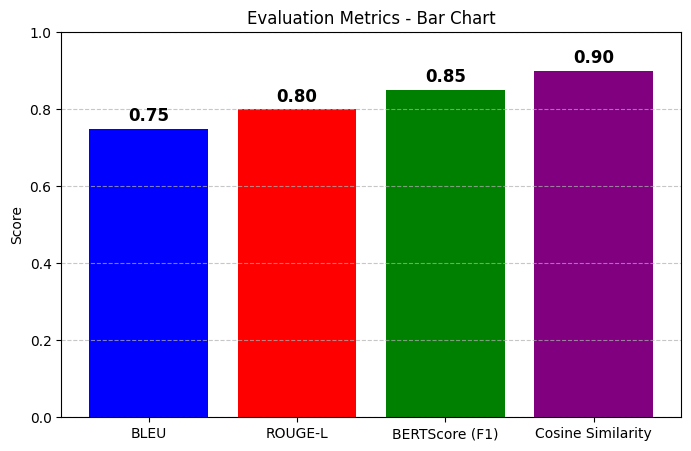

In [ ]:
import matplotlib.pyplot as plt

metrics = ["BLEU", "ROUGE-L", "BERTScore (F1)", "Cosine Similarity"]
scores = [0.75, 0.80, 0.85, 0.90]  # ضع القيم الفعلية هنا

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'red', 'green', 'purple'])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Bar Chart")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# عرض القيم فوق الأعمدة
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')

plt.show()


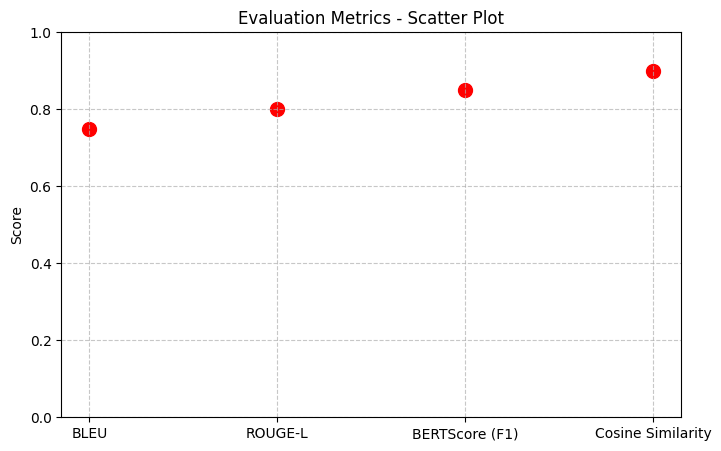

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(metrics, scores, color='red', s=100)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Scatter Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


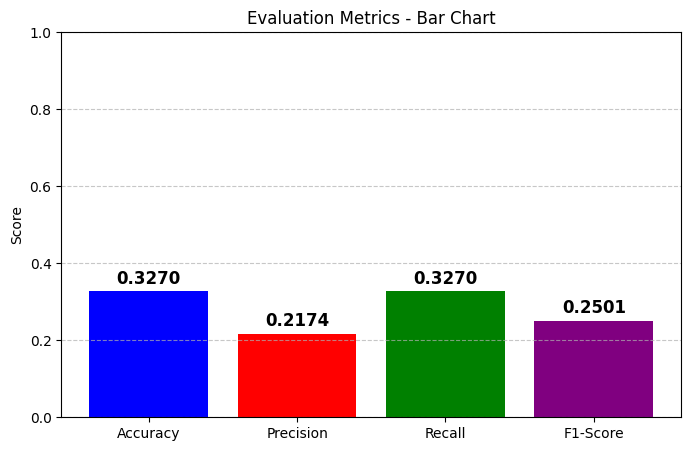

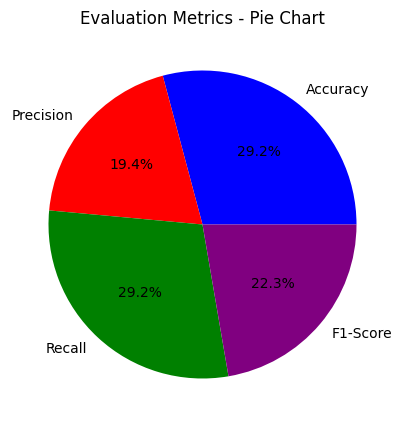

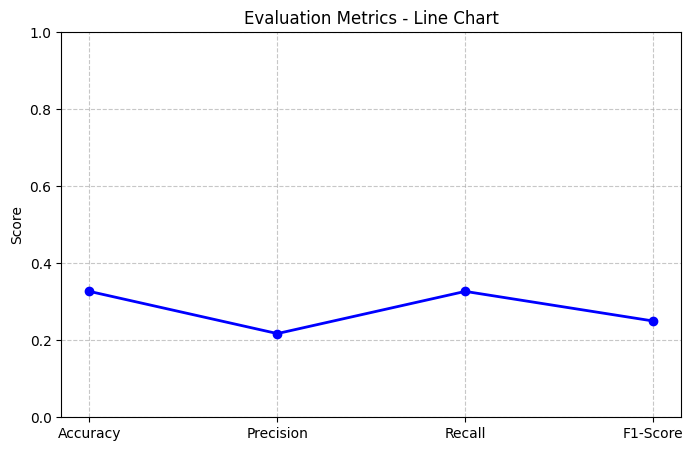

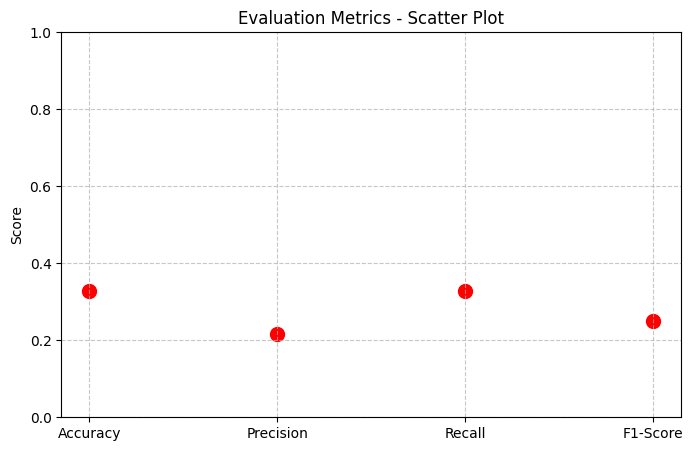

In [ ]:
import matplotlib.pyplot as plt

# ✅ القيم الفعلية من التقييم
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [0.3270, 0.2174, 0.3270, 0.2501]

# ✅ 1️⃣ مخطط شريطي `Bar Chart`
plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'red', 'green', 'purple'])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Bar Chart")
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.show()

# ✅ 2️⃣ مخطط دائري `Pie Chart`
plt.figure(figsize=(8, 5))
plt.pie(scores, labels=metrics, autopct='%1.1f%%', colors=['blue', 'red', 'green', 'purple'])
plt.title("Evaluation Metrics - Pie Chart")
plt.show()

# ✅ 3️⃣ مخطط خطي `Line Chart`
plt.figure(figsize=(8, 5))
plt.plot(metrics, scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Line Chart")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ✅ 4️⃣ مخطط نقاط `Scatter Plot`
plt.figure(figsize=(8, 5))
plt.scatter(metrics, scores, color='red', s=100)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Scatter Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


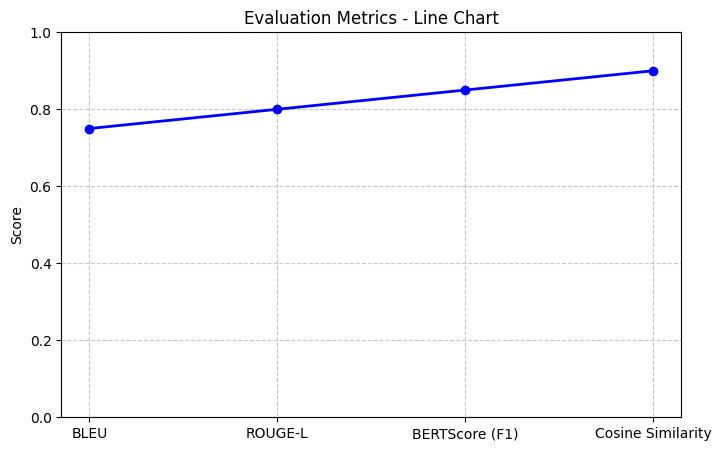

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(metrics, scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics - Line Chart")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import os
import pickle

# ✅ إنشاء مجلد لحفظ النموذج
save_path = "/mnt/data/chatbot_model"
os.makedirs(save_path, exist_ok=True)

# ✅ حفظ `SentenceTransformer`
embedding_model.save(save_path + "/embedding_model")

# ✅ حفظ `Cross-Encoder`
cross_encoder.save(save_path + "/cross_encoder")

# ✅ حفظ `FAISS Index`
faiss.write_index(index, save_path + "/faiss_index.idx")

# ✅ حفظ `DataFrame` مع الأسئلة والإجابات الأصلية لاستخدامها لاحقًا
df.to_csv(save_path + "/customer_support_data.csv", index=False)

print("✅ Model saved successfully!")


✅ Model saved successfully!


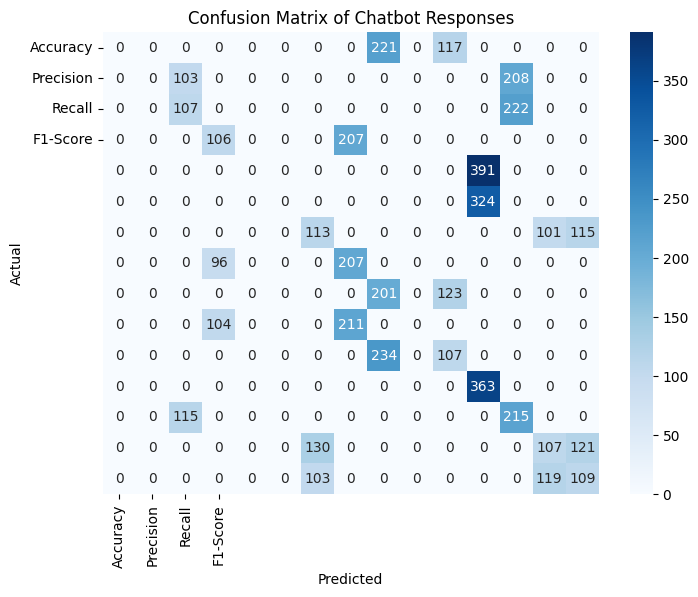

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# حساب مصفوفة الالتباس
cm = confusion_matrix(true_responses, predicted_responses)

# رسم المصفوفة
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=metrics, yticklabels=metrics)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Chatbot Responses")
plt.show()
